In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as ps
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.transforms import Bbox
from matplotlib.ticker import FuncFormatter
import torch
import pandas as pd
import torch.nn as nn
import optuna
from models import CondSM
from pathlib import Path
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

print(pd.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

def fit_affine_to_target(y_sm: torch.Tensor, y_tgt: torch.Tensor, eps: float = 1e-12, clamp_gain_nonneg: bool = False):
    """
    Fit a,b minimizing ||a*y_sm + b - y_tgt||^2 (least squares with intercept).
    Returns: (a, b, y_aff)
    """
    if not torch.is_tensor(y_sm):
        y_sm = torch.as_tensor(y_sm)
    if not torch.is_tensor(y_tgt):
        y_tgt = torch.as_tensor(y_tgt)
        
    y = y_sm.float().flatten()
    t = y_tgt.float().flatten()

    y_mean = y.mean()
    t_mean = t.mean()

    y0 = y - y_mean
    t0 = t - t_mean

    var_y = (y0 * y0).mean()
    cov_yt = (y0 * t0).mean()

    a = cov_yt / (var_y + eps)
    if clamp_gain_nonneg:
        a = torch.clamp(a, min=0.0)

    b = t_mean - a * y_mean
    y_aff = a * y_sm + b
    return a, b, y_aff

def mse(a, b):
    """Mean squared error between two 1D arrays/tensors."""
    if not torch.is_tensor(a):
        a = torch.as_tensor(a)
    if not torch.is_tensor(b):
        b = torch.as_tensor(b)
    a = a.float().flatten()
    b = b.float().flatten()
    return torch.mean((a - b) ** 2)

2.2.3
cuda


0.14845914 5.023506
original curve mse: tensor(0.1829)


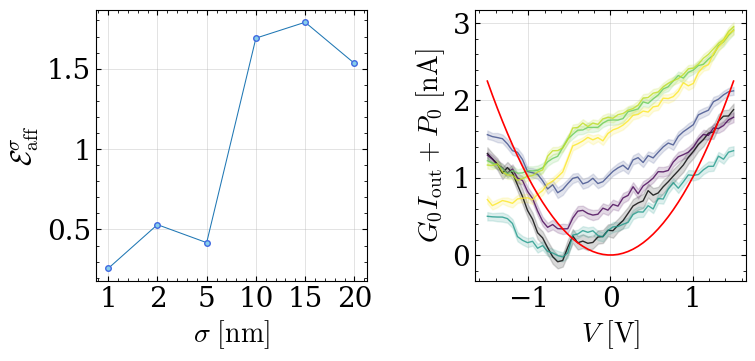

In [6]:
data_type = 'grad_towards_1e7'
func_type = 'Parabola'

label_dict = {
    "uni_1e7": r"Uniform: $\mathbf{Sigmoid}$",
    "data_vMB_ring_1e7": "Annular: $\mathbf{Parabola}$",
    "grad_towards_1e7": "Gradient towards the output: $\mathbf{Sine}$",
    "grad_away_1e7": "Gradient away from the output: $\mathbf{Cubic}$"
}

n = 50
x = torch.linspace(-1.5, 1.5, n)
if func_type == 'Parabola':
    y_tgt = x ** 2
elif func_type == 'ReLU':
    m = nn.ReLU()
    y_tgt = m(x)
elif func_type == 'Sigmoid':
    m = nn.Sigmoid()
    y_tgt = m(4*x)
elif func_type == 'Cubic':
    y_tgt = x **3
elif func_type == 'Sine':
    y_tgt = torch.sin(3*x)

dopant_profile_path = Path(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/configs/jiggled_configs/')

i_scale = 1e21
noise_strengths = [1, 2, 5, 10, 15, 20]
noise_vals = np.array(noise_strengths)

ref_data = np.load(
    f"/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/{data_type}_{func_type}_topK/"
    f"random_mse_func_type={func_type}_data_type={data_type}_topk=0.npz"
)
i_ref = ref_data['current'] * i_scale
gain_global, offset_global, i_aff_global = fit_affine_to_target(i_ref, y_tgt)
gain_global, offset_global = gain_global.numpy(), offset_global.numpy()
print(gain_global, offset_global)

cal_mode = 'global'    
label_fs = 20
tick_label_fs = 20
d_profiles = []
i_outs = []
i_errs = []
e_aff_scores = []
gains = []
offsets = []
for k in range(len(noise_strengths)):
    d_profiles.append(np.loadtxt(Path(dopant_profile_path / f"jiggled_{k}.txt")))
    data_k = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/{data_type}_{func_type}_jiggling/random_mse_func_type={func_type}_data_type={data_type}_jiggled_k={k}.npz")
    i_o = data_k['current'] * i_scale
    i_err = data_k['sem'] * i_scale
    g_0 = 0.0
    p_0 = 0.0
    if cal_mode == 'global':
        i_o_aff = i_o * gain_global + offset_global
        i_err_aff = i_err * np.abs(gain_global)
    elif cal_mode == 'recal':
        g_0, p_0, i_o_aff = fit_affine_to_target(i_o, y_tgt)
        g_0, p_0, i_o_aff = g_0.numpy(), p_0.numpy(), i_o_aff.numpy()
        i_err_aff = i_err * np.abs(g_0)
    gains.append(g_0)
    offsets.append(p_0)
        
    e_aff = mse(i_o_aff, y_tgt)
    e_aff_scores.append(e_aff)
    
    i_outs.append(i_o_aff)
    i_errs.append(i_err_aff)

data_no_noise = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/random_mse_func_type={func_type}_data_type={data_type}_maxl2=2.0_input_idx=3_seed=42.npz')
i_org = data_no_noise['current'] * i_scale
i_err_org = data_no_noise['sem'] * i_scale

g_0_org, p_org_0, i_org_aff = fit_affine_to_target(i_org, y_tgt)
g_0_org, p_org_0, i_org_aff = g_0_org.numpy(), p_org_0.numpy(), i_org_aff.numpy()
print("original curve mse:", mse(y_tgt, i_org_aff))

i_err_org = i_err_org * np.abs(g_0_org)

"""fig, ax = plt.subplots(ncols=2, figsize=(5, 5))
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(direction='in', which='both')
ax.grid(lw=0.5, alpha=0.5)
ax.set_box_aspect(1)"""
fig = plt.figure(figsize=(10, 5))

# Reserve a fixed right margin for the legend (so axes don't change width)
L, R = 0.15, 0.95
R = 0.8
B, T = 0.05, 0.98
gs = GridSpec(
    1, 2, figure=fig,
    left=L, right=R,  # <--- fixed axes area
    bottom=B, top=T,  # <--- fixed axes area
    wspace=0.40
)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])

for a in (ax0, ax1):
    a.minorticks_on()
    a.tick_params(top=True, right=True, which='both')
    a.tick_params(direction='in', which='both')
    a.grid(lw=0.5, alpha=0.5)
    a.set_box_aspect(1)
ax1.plot(np.linspace(-1.5, 1.5, 50), y_tgt, lw=1.2, c='r', label='$T(V_i)$', zorder=5)
#ax.plot(np.linspace(-1.5, 1.5, 50), i_org_aff, lw=2.5, c='r', alpha=0.5, label='$\sigma = 0 \, \mathrm{nm}$')
"""ORIGINAL CURVE (sigma=0)"""
ax1.fill_between(np.linspace(-1.5, 1.5, 50), i_org_aff - i_err_org*1.96, i_org_aff + i_err_org*1.96, alpha=0.15, color='k')
ax1.plot(np.linspace(-1.5, 1.5, 50), i_org_aff, lw=1., alpha=0.8, label='$\sigma = 0 \, \mathrm{nm}$', color='k')

ax1.set_xlabel("$V \, \, [\mathrm{V}]$", fontsize=label_fs)
ax1.set_ylabel("$G_0 I_{\mathrm{out}} + P_0 \, \, [\mathrm{nA}]$", fontsize=label_fs)
ax1.xaxis.set_label_position('bottom')
ax1.tick_params(labelbottom=True)
ax1.tick_params(labelsize=tick_label_fs, which='both')
"""axins = inset_axes(ax, width="30%", height="30%", loc="upper left", borderpad=1.)
axins.tick_params(which='both', direction='in', labelsize=9)
#axins.tick_params(axis='y', labelrotation=90)
axins.tick_params(axis='x', labelbottom=True, labeltop=False)
axins.set_xticks(np.arange(1, len(noise_strengths)+1, 1))
axins.set_xticklabels([str(ns) for ns in noise_strengths])
axins.set_xlabel('$\sigma \, \, [\mathrm{nm}]$', fontsize=9)
axins.xaxis.set_label_position('bottom')
axins.yaxis.set_label_position('right')
axins.tick_params(axis='y', labelleft=False, labelright=True)
axins.set_ylabel('$\mathcal{E}_{\mathrm{aff}}$')
axins.minorticks_on()
axins.tick_params(top=True, right=True, which='both')
axins.set_yscale('log')
axins.grid(lw=0.5, alpha=0.5, which='both', axis='y')
axins.grid(lw=0.5, alpha=0.5, which='major', axis='x')

axins.plot(np.arange(1, len(noise_strengths)+1, 1), e_aff_scores, marker="o", lw=0.75, markersize=4, markeredgecolor='royalblue', markerfacecolor='skyblue')"""

def ten_e_formatter(val, pos=None):
    # val is the tick value (e.g., 0.01)
    if val <= 0:
        return ""
    exp = int(round(np.log10(val)))
    # Only label exact powers of 10 (major ticks)
    if np.isclose(val, 10**exp):
        return f"10e{exp}"   # e.g. 10e-2
    return ""
ax0.tick_params(which='both', direction='in', labelsize=tick_label_fs)
#ax0.tick_params(axis='y', labelrotation=90)
ax0.tick_params(axis='x', labelbottom=True, labeltop=False)
ax0.set_xticks(np.arange(1, len(noise_strengths)+1, 1))
ax0.set_xticklabels([str(ns) for ns in noise_strengths])
ax0.set_xlabel('$\sigma \, \, [\mathrm{nm}]$', fontsize=label_fs)
ax0.xaxis.set_label_position('bottom')
ax0.yaxis.set_label_position('left')
ax0.tick_params(axis='y', labelleft=True, labelright=False)
ax0.set_ylabel('$\mathcal{E}_{\mathrm{aff}}^{\sigma}$', fontsize=label_fs)
ax0.minorticks_on()
ax0.tick_params(top=True, right=True, which='both')
#axins.set_yscale('log')
ax0.grid(lw=0.5, alpha=0.5, which='major', axis='y')
ax0.grid(lw=0.5, alpha=0.5, which='major', axis='x')

ax0.plot(np.arange(1, len(noise_strengths)+1, 1), e_aff_scores, marker="o", lw=0.75, markersize=4, markeredgecolor='royalblue', markerfacecolor='skyblue')
"""if cal_mode == 'recal':
    fig.suptitle(f"{label_dict[data_type]}", fontdict={"fontsize": 30}, y=0.85)"""

"""if cal_mode == 'recal':
    ax0.set_title(f"{label_dict[data_type]}", fontsize=20)"""
#axins.yaxis.set_major_locator(mticker.LogLocator(base=10))
#axins.yaxis.set_major_formatter(mticker.FuncFormatter(ten_e_formatter))
#axins.yaxis.set_minor_formatter(mticker.NullFormatter())

cmap = plt.get_cmap('viridis')
norm = mpl.colors.LogNorm(vmin=noise_vals.min(), vmax=noise_vals.max())

for i in range(len(noise_strengths)):
    ax1.fill_between(np.linspace(-1.5, 1.5, 50), i_outs[i] - i_errs[i]*1.96, i_outs[i] + i_errs[i]*1.96, alpha=0.15, color=cmap(norm(noise_vals[i])))
    ax1.plot(np.linspace(-1.5, 1.5, 50), i_outs[i], lw=1., alpha=0.8, color=cmap(norm(noise_vals[i])))#, label=rf'$\sigma={noise_strengths[i]} \, \mathrm{{nm}}$'

ax0.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2g'))
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2g'))
#axins_pos = axins.get_position()
#axins.set_position([axins_pos.x0+0.02, axins_pos.y0, axins_pos.width, axins_pos.height])+
"""if data_type == 'uni_1e7' and cal_mode == 'recal':
    ax1.legend(ncols=2, frameon=False)"""
"""if cal_mode == 'recal' and data_type == 'uni_1e7':
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="upper left",
        bbox_to_anchor=(0.81, 0.88),  # fixed figure coords
        frameon=False,
        fontsize=12,
        ncol=1,
    )"""
"""if cal_mode == 'global':
    fig.suptitle(f"Fixed-calibration: $G_0={gain_global:.2f}$, $P_0={offset_global:.2f}$", y=0.87, fontsize=12, ha='center')
elif cal_mode == 'recal':
    fig.suptitle("Re-calibration", y=0.87, fontsize=12, ha='center')"""
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
pos = ax1.get_position() 
if data_type == 'uni_1e7' and cal_mode == 'recal':
    ax1.legend(fontsize=12)
    cax = fig.add_axes([pos.x1 + 0.015, pos.y0, 0.02, pos.height])  # [left, bottom, width, height] in figure coords
    cbar = fig.colorbar(sm, cax=cax)
    ticks = [1, 2, 5, 10, 15, 20]
    cbar.set_ticks(ticks)
    cbar.ax.tick_params(labelsize=tick_label_fs)
    
    # show them as normal numbers (no 10^x)
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:g}"))
    cbar.set_label(r'$\sigma \, [\mathrm{nm}]$', fontsize=label_fs)
#fig.subplots_adjust(wspace=.3)
#fig.subplots_adjust(wspace=0.4, right=0.8)
#fig.subplots_adjust(top=0.75, bottom=0.2)  # tweak numbers
#bbox_inches = Bbox.from_extents(0.0, 0.0, 5.0, 2.0)
#bbox = mtransforms.Bbox.from_extents(L, B, R, T).transformed(fig.transFigure)
fig.savefig(f'{cal_mode}_{data_type}_{func_type}.pdf', bbox_inches=None)

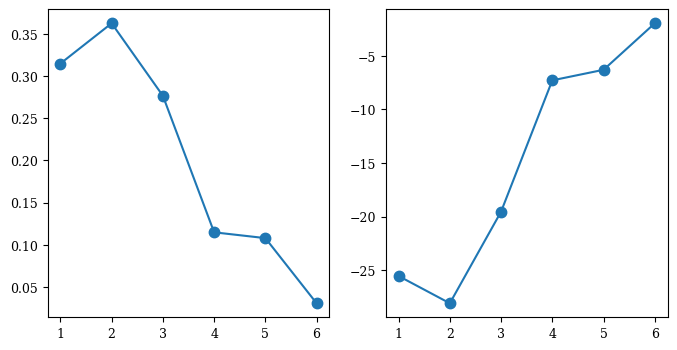

In [23]:
fig, ax = plt.subplots(ncols=2, figsize=(8, 4))
ax[0].plot(np.arange(1, len(gains)+1, 1), gains, marker='o', markersize=7.5)
ax[1].plot(np.arange(1, len(offsets)+1, 1), offsets, marker='o', markersize=7.5)

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from pathlib import Path
import torch
import torch.nn as nn


def plot_all_global_vs_recal_grid(
    data_dict: dict,
    noise_strengths=(1, 2, 5, 10, 15, 20),
    n: int = 50,
    x_min: float = -1.5,
    x_max: float = 1.5,
    i_scale: float = 1e21,
    label_fs: int = 13,
    tick_label_fs: int = 13,
    seed_curve_path: str = "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/"
                          "random_mse_func_type={func_type}_data_type={data_type}_maxl2=2.0_input_idx=3_seed=42.npz",
    ref_curve_path: str = "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/"
                         "{data_type}_{func_type}_topK/random_mse_func_type={func_type}_data_type={data_type}_topk=0.npz",
    jiggled_curve_path: str = "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/"
                             "{data_type}_{func_type}_jiggling/random_mse_func_type={func_type}_data_type={data_type}_jiggled_k={k}.npz",
    dopant_profile_dir: str = "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/"
                             "{data_type}/configs/jiggled_configs/",
    out_pdf: str | None = None,
    # REQUIRED
    fit_affine_to_target=None,
    mse=None,
    # layout knobs
    figsize=(18, 8),
    wspace=0.25,
    hspace=0.10,
    left=0.05,
    right=0.98,
    bottom=0.08,
    top=0.92,
    legend=True,
):
    """
    Makes ONE big figure containing all datasets in `data_dict`.

    Layout:
      rows = 2  (global, recal)
      cols = 2 * len(data_dict)  (per dataset: [E vs sigma, curves])

    You must pass fit_affine_to_target and mse (same as your single plot function).
    """
    if fit_affine_to_target is None or mse is None:
        raise ValueError("Pass fit_affine_to_target=... and mse=...")

    noise_strengths = list(noise_strengths)
    noise_vals = np.array(noise_strengths, dtype=float)
    cmap = plt.get_cmap("viridis")
    norm = mpl.colors.LogNorm(vmin=noise_vals.min(), vmax=noise_vals.max())

    # target x for plotting
    x = torch.linspace(x_min, x_max, n)
    x_np = np.linspace(x_min, x_max, n)

    # figure + gridspec: 2 rows, 2*D cols
    D = len(data_dict)
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        2, 2 * D, figure=fig,
        left=left, right=right, bottom=bottom, top=top,
        wspace=wspace, hspace=hspace
    )

    # axes[r, c] where c goes over 2*D columns
    axes = np.empty((2, 2 * D), dtype=object)
    for r in range(2):
        for c in range(2 * D):
            axes[r, c] = fig.add_subplot(gs[r, c])
            a = axes[r, c]
            a.minorticks_on()
            a.tick_params(top=True, right=True, which="both", direction="in")
            a.grid(lw=0.5, alpha=0.5)
            a.tick_params(labelsize=tick_label_fs, which="both")

    # small helper: target function
    def make_target(func_type: str):
        if func_type == "Parabola":
            return x ** 2
        if func_type == "ReLU":
            return nn.ReLU()(x)
        if func_type == "Sigmoid":
            return nn.Sigmoid()(4 * x)
        if func_type == "Cubic":
            return x ** 3
        if func_type == "Sine":
            return torch.sin(3 * x)
        raise ValueError(f"Unknown func_type={func_type}")

    # we’ll collect legend handles from the last “curves” axis
    legend_handles, legend_labels = None, None

    for j, (data_type, func_type) in enumerate(data_dict.items()):
        y_tgt = make_target(func_type)

        dopant_profile_path = Path(dopant_profile_dir.format(data_type=data_type))
        ref_path = ref_curve_path.format(data_type=data_type, func_type=func_type)
        seed_path = seed_curve_path.format(data_type=data_type, func_type=func_type)

        # global affine from ref
        ref_data = np.load(ref_path)
        i_ref = ref_data["current"] * i_scale
        gain_global, offset_global, _ = fit_affine_to_target(i_ref, y_tgt)
        gain_global = gain_global.numpy()
        offset_global = offset_global.numpy()

        # sigma=0 baseline (recal)
        data_no_noise = np.load(seed_path)
        i_org = data_no_noise["current"] * i_scale
        i_err_org = data_no_noise["sem"] * i_scale
        g0_org, p0_org, i_org_aff = fit_affine_to_target(i_org, y_tgt)
        g0_org = g0_org.numpy()
        i_org_aff = i_org_aff.numpy()
        i_err_org_aff = i_err_org * np.abs(g0_org)

        def compute_mode(cal_mode: str):
            i_outs, i_errs, e_aff_scores = [], [], []
            for k in range(len(noise_strengths)):
                # (optional) keep dopants if you want:
                _ = np.loadtxt(dopant_profile_path / f"jiggled_{k}.txt")

                data_k = np.load(jiggled_curve_path.format(
                    data_type=data_type, func_type=func_type, k=k
                ))
                i_o = data_k["current"] * i_scale
                i_err = data_k["sem"] * i_scale

                if cal_mode == "global":
                    i_o_aff = i_o * gain_global + offset_global
                    i_err_aff = i_err * np.abs(gain_global)
                else:  # recal
                    g_0, p_0, i_o_aff = fit_affine_to_target(i_o, y_tgt)
                    g_0 = g_0.numpy()
                    i_o_aff = i_o_aff.numpy()
                    i_err_aff = i_err * np.abs(g_0)

                e_aff_scores.append(mse(i_o_aff, y_tgt))
                i_outs.append(i_o_aff)
                i_errs.append(i_err_aff)

            return np.array(e_aff_scores, float), i_outs, i_errs

        e_g, outs_g, errs_g = compute_mode("global")
        e_r, outs_r, errs_r = compute_mode("recal")

        # column pair for this dataset
        cE = 2 * j
        cC = 2 * j + 1

        # ===== Row 0: global
        axE0 = axes[0, cE]
        axC0 = axes[0, cC]

        axE0.set_title(f"{data_type}\n{func_type}", fontsize=label_fs, pad=8)
        axE0.set_xticks(np.arange(1, len(noise_strengths) + 1))
        axE0.set_xticklabels([str(ns) for ns in noise_strengths])
        axE0.set_ylabel(r"$\mathcal{E}_{\mathrm{aff}}^{\sigma}$", fontsize=label_fs)
        axE0.plot(np.arange(1, len(noise_strengths) + 1), e_g, marker="o", lw=0.75, markersize=3)
        axE0.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))

        axC0.plot(x_np, y_tgt.numpy(), lw=1.2, c="r", label=r"$T(V_i)$", zorder=5)
        axC0.fill_between(x_np, i_org_aff - i_err_org_aff * 1.96, i_org_aff + i_err_org_aff * 1.96, alpha=0.15, color="k")
        axC0.plot(x_np, i_org_aff, lw=1.0, alpha=0.8, color="k", label=r"$\sigma = 0$")

        for i, ns in enumerate(noise_strengths):
            color = cmap(norm(noise_vals[i]))
            axC0.fill_between(x_np, outs_g[i] - errs_g[i] * 1.96, outs_g[i] + errs_g[i] * 1.96, alpha=0.15, color=color)
            axC0.plot(x_np, outs_g[i], lw=1.0, alpha=0.8, color=color, label=rf"$\sigma={ns}$")

        axC0.set_title(rf"Fixed: $G_0={gain_global:.2g}$, $P_0={offset_global:.2g}$", fontsize=label_fs, pad=8)
        axC0.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))

        # ===== Row 1: recal
        axE1 = axes[1, cE]
        axC1 = axes[1, cC]

        axE1.set_xticks(np.arange(1, len(noise_strengths) + 1))
        axE1.set_xticklabels([str(ns) for ns in noise_strengths])
        axE1.set_xlabel(r"$\sigma \, [\mathrm{nm}]$", fontsize=label_fs)
        axE1.set_ylabel(r"$\mathcal{E}_{\mathrm{aff}}^{\sigma}$", fontsize=label_fs)
        axE1.plot(np.arange(1, len(noise_strengths) + 1), e_r, marker="o", lw=0.75, markersize=3)
        axE1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))

        axC1.plot(x_np, y_tgt.numpy(), lw=1.2, c="r", label=r"$T(V_i)$", zorder=5)
        axC1.fill_between(x_np, i_org_aff - i_err_org_aff * 1.96, i_org_aff + i_err_org_aff * 1.96, alpha=0.15, color="k")
        axC1.plot(x_np, i_org_aff, lw=1.0, alpha=0.8, color="k", label=r"$\sigma = 0$")

        for i, ns in enumerate(noise_strengths):
            color = cmap(norm(noise_vals[i]))
            axC1.fill_between(x_np, outs_r[i] - errs_r[i] * 1.96, outs_r[i] + errs_r[i] * 1.96, alpha=0.15, color=color)
            axC1.plot(x_np, outs_r[i], lw=1.0, alpha=0.8, color=color, label=rf"$\sigma={ns}$")

        axC1.set_title("Re-calibration", fontsize=label_fs, pad=8)
        axC1.set_xlabel(r"$V \, [\mathrm{V}]$", fontsize=label_fs)
        axC1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))

        # reduce repeated y-label clutter: keep only first dataset’s ylabels if you want
        if j != 0:
            axE0.set_ylabel("")
            axE1.set_ylabel("")
            axC0.set_ylabel("")
            axC1.set_ylabel("")
        else:
            axC0.set_ylabel(r"$G_0 I_{\mathrm{out}} + P_0 \, [\mathrm{nA}]$", fontsize=label_fs)
            axC1.set_ylabel(r"$G_0 I_{\mathrm{out}} + P_0 \, [\mathrm{nA}]$", fontsize=label_fs)

        # collect legend from last curves axis (recal row is fine)
        legend_handles, legend_labels = axC1.get_legend_handles_labels()

    # one shared legend for whole figure
    if legend and legend_handles is not None:
        fig.legend(
            legend_handles, legend_labels,
            loc="center right",
            bbox_to_anchor=(0.995, 0.5),
            bbox_transform=fig.transFigure,
            frameon=False,
            fontsize=11,
            ncol=1,
        )

    if out_pdf is not None:
        fig.savefig(out_pdf, bbox_inches="tight")

    return fig
def make_global_vs_recal_plots(
    data_type: str = "uni_1e7",
    func_type: str = "Sigmoid",
    noise_strengths=(1, 2, 5, 10, 15, 20),
    n: int = 50,
    x_min: float = -1.5,
    x_max: float = 1.5,
    i_scale: float = 1e21,
    label_fs: int = 13,
    tick_label_fs: int = 13,
    seed_curve_path: str = "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/"
                   "random_mse_func_type={func_type}_data_type={data_type}_maxl2=2.0_input_idx=3_seed=42.npz",
    ref_curve_path: str = "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/"
                   "{data_type}_{func_type}_topK/random_mse_func_type={func_type}_data_type={data_type}_topk=0.npz",
    jiggled_curve_path: str = "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/"
                   "{data_type}_{func_type}_jiggling/random_mse_func_type={func_type}_data_type={data_type}_jiggled_k={k}.npz",
    dopant_profile_dir: str = "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/"
                   "{data_type}/configs/jiggled_configs/",
    out_pdf: str | None = None,
    # REQUIRED: pass your own implementations
    fit_affine_to_target=None,
    mse=None,
):
    """
    Produces one figure with BOTH calibration modes:
      Row 0: global   (left: E_aff^sigma vs sigma, right: curves)
      Row 1: recal    (left: E_aff^sigma vs sigma, right: curves)

    You must pass:
      - fit_affine_to_target(i, y_tgt) -> (gain, offset, i_aff)
      - mse(y_pred, y_true) -> float
    """
    if fit_affine_to_target is None or mse is None:
        raise ValueError("Pass fit_affine_to_target=... and mse=...")

    # --- target function
    x = torch.linspace(x_min, x_max, n)
    if func_type == "Parabola":
        y_tgt = x ** 2
    elif func_type == "ReLU":
        y_tgt = nn.ReLU()(x)
    elif func_type == "Sigmoid":
        y_tgt = nn.Sigmoid()(4 * x)
    elif func_type == "Cubic":
        y_tgt = x ** 3
    elif func_type == "Sine":
        y_tgt = torch.sin(3 * x)
    else:
        raise ValueError(f"Unknown func_type={func_type}")

    x_np = np.linspace(x_min, x_max, n)
    noise_strengths = list(noise_strengths)
    noise_vals = np.array(noise_strengths, dtype=float)

    # --- paths
    dopant_profile_path = Path(dopant_profile_dir.format(data_type=data_type))
    ref_path = ref_curve_path.format(data_type=data_type, func_type=func_type)
    seed_path = seed_curve_path.format(data_type=data_type, func_type=func_type)

    # --- global affine from ref
    ref_data = np.load(ref_path)
    i_ref = ref_data["current"] * i_scale
    gain_global, offset_global, _ = fit_affine_to_target(i_ref, y_tgt)
    gain_global, offset_global = gain_global.numpy(), offset_global.numpy()

    # --- original (sigma=0), always recal to target for plotting baseline in both modes
    data_no_noise = np.load(seed_path)
    i_org = data_no_noise["current"] * i_scale
    i_err_org = data_no_noise["sem"] * i_scale
    g0_org, p0_org, i_org_aff = fit_affine_to_target(i_org, y_tgt)
    g0_org, p0_org, i_org_aff = g0_org.numpy(), p0_org.numpy(), i_org_aff.numpy()
    i_err_org_aff = i_err_org * np.abs(g0_org)

    # --- helper to compute outputs for a given cal_mode
    def compute_mode(cal_mode: str):
        i_outs, i_errs, e_aff_scores = [], [], []
        gains, offsets = [], []
        d_profiles = []

        for k in range(len(noise_strengths)):
            # keep dopant profiles if you later want them; not used in plotting here
            d_profiles.append(np.loadtxt(dopant_profile_path / f"jiggled_{k}.txt"))

            data_k = np.load(jiggled_curve_path.format(
                data_type=data_type, func_type=func_type, k=k
            ))
            i_o = data_k["current"] * i_scale
            i_err = data_k["sem"] * i_scale

            if cal_mode == "global":
                i_o_aff = i_o * gain_global + offset_global
                i_err_aff = i_err * np.abs(gain_global)
                g_0, p_0 = 0.0, 0.0
            elif cal_mode == "recal":
                g_0, p_0, i_o_aff = fit_affine_to_target(i_o, y_tgt)
                g_0, p_0, i_o_aff = g_0.numpy(), p_0.numpy(), i_o_aff.numpy()
                i_err_aff = i_err * np.abs(g_0)
            else:
                raise ValueError("cal_mode must be 'global' or 'recal'")

            gains.append(g_0)
            offsets.append(p_0)
            e_aff_scores.append(mse(i_o_aff, y_tgt))
            i_outs.append(i_o_aff)
            i_errs.append(i_err_aff)

        return {
            "d_profiles": d_profiles,
            "i_outs": i_outs,
            "i_errs": i_errs,
            "e_aff_scores": np.array(e_aff_scores, dtype=float),
            "gains": np.array(gains, dtype=float),
            "offsets": np.array(offsets, dtype=float),
        }

    global_res = compute_mode("global")
    recal_res = compute_mode("recal")

    # --- plotting
    fig = plt.figure(figsize=(12, 10))
    L, R = 0.10, 0.78
    B, T = 0.08, 0.95
    gs = GridSpec(
        2, 2, figure=fig,
        left=L, right=R,
        bottom=B, top=T,
        wspace=0.3, hspace=0.00
    )

    axes = np.array([
        [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
        [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
    ])

    for r in range(2):
        for c in range(2):
            a = axes[r, c]
            a.minorticks_on()
            a.tick_params(top=True, right=True, which="both")
            a.tick_params(direction="in", which="both")
            a.grid(lw=0.5, alpha=0.5)
            a.set_box_aspect(1)
            a.tick_params(labelsize=tick_label_fs, which="both")

    cmap = plt.get_cmap("viridis")
    norm = mpl.colors.LogNorm(vmin=noise_vals.min(), vmax=noise_vals.max())

    def draw_row(row_idx: int, cal_mode: str, res: dict):
        axE = axes[row_idx, 0]
        axC = axes[row_idx, 1]

        # left: error vs sigma
        axE.set_xticks(np.arange(1, len(noise_strengths) + 1, 1))
        axE.set_xticklabels([str(ns) for ns in noise_strengths])
        axE.tick_params(labelbottom=True, bottom=True)
        if row_idx == 1:
            axE.tick_params(labelbottom=False, bottom=False)
            axE.set_xlabel(r"$\sigma \, \, [\mathrm{nm}]$", fontsize=label_fs)
        axE.set_ylabel(r"$\mathcal{E}_{\mathrm{aff}}^{\sigma}$", fontsize=label_fs)
        axE.grid(lw=0.5, alpha=0.5, which="major", axis="y")
        axE.grid(lw=0.5, alpha=0.5, which="major", axis="x")
        axE.plot(
            np.arange(1, len(noise_strengths) + 1, 1),
            res["e_aff_scores"],
            marker="o", lw=0.75, markersize=4,
            markeredgecolor="royalblue",
            markerfacecolor="skyblue",
        )
        axE.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))

        # right: curves
        axC.plot(x_np, y_tgt.numpy(), lw=1.2, c="r", label=r"$T(V_i)$", zorder=5)

        # baseline sigma=0 curve (same for both rows)
        axC.fill_between(
            x_np,
            i_org_aff - i_err_org_aff * 1.96,
            i_org_aff + i_err_org_aff * 1.96,
            alpha=0.15, color="k"
        )
        axC.plot(
            x_np, i_org_aff, lw=1.0, alpha=0.8,
            label=r"$\sigma = 0 \, \mathrm{nm}$", color="k"
        )

        for i, ns in enumerate(noise_strengths):
            color = cmap(norm(noise_vals[i]))
            axC.fill_between(
                x_np,
                res["i_outs"][i] - res["i_errs"][i] * 1.96,
                res["i_outs"][i] + res["i_errs"][i] * 1.96,
                alpha=0.15, color=color
            )
            axC.plot(
                x_np, res["i_outs"][i], lw=1.0, alpha=0.8,
                label=rf"$\sigma={ns} \, \mathrm{{nm}}$", color=color
            )
        axC.tick_params(labelbottom=True, bottom=True)
        if row_idx == 1:
            axC.tick_params(labelbottom=False, bottom=False)
            axC.set_xlabel(r"$V \, \, [\mathrm{V}]$", fontsize=label_fs)
        axC.set_ylabel(r"$G_0 I_{\mathrm{out}} + P_0 \, \, [\mathrm{nA}]$", fontsize=label_fs)
        axC.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))

        # row title
        if cal_mode == "global":
            title = rf"Fixed: $G_0={gain_global:.2g}$, $P_0={offset_global:.2g}$"
        else:
            title = "Re-calibration (per $\sigma$)"
        axC.set_title(title, fontsize=label_fs, pad=10)

        # legend: only for recal row (like you did), but you can switch if you want
        if cal_mode == "recal":
            handles, labels = axC.get_legend_handles_labels()
            fig.legend(
                handles, labels,
                #loc="upper right",
                bbox_to_anchor=(0.92, 0.93),
                bbox_transform=fig.transFigure,
                frameon=False,
                fontsize=14,
                ncol=1,
            )

    draw_row(0, "global", global_res)
    draw_row(1, "recal", recal_res)

    if out_pdf is None:
        out_pdf = f"both_global_vs_recal_{data_type}_{func_type}.pdf"
    fig.savefig(out_pdf, bbox_inches='tight')
    return fig, {"global": global_res, "recal": recal_res, "gain_global": gain_global, "offset_global": offset_global}

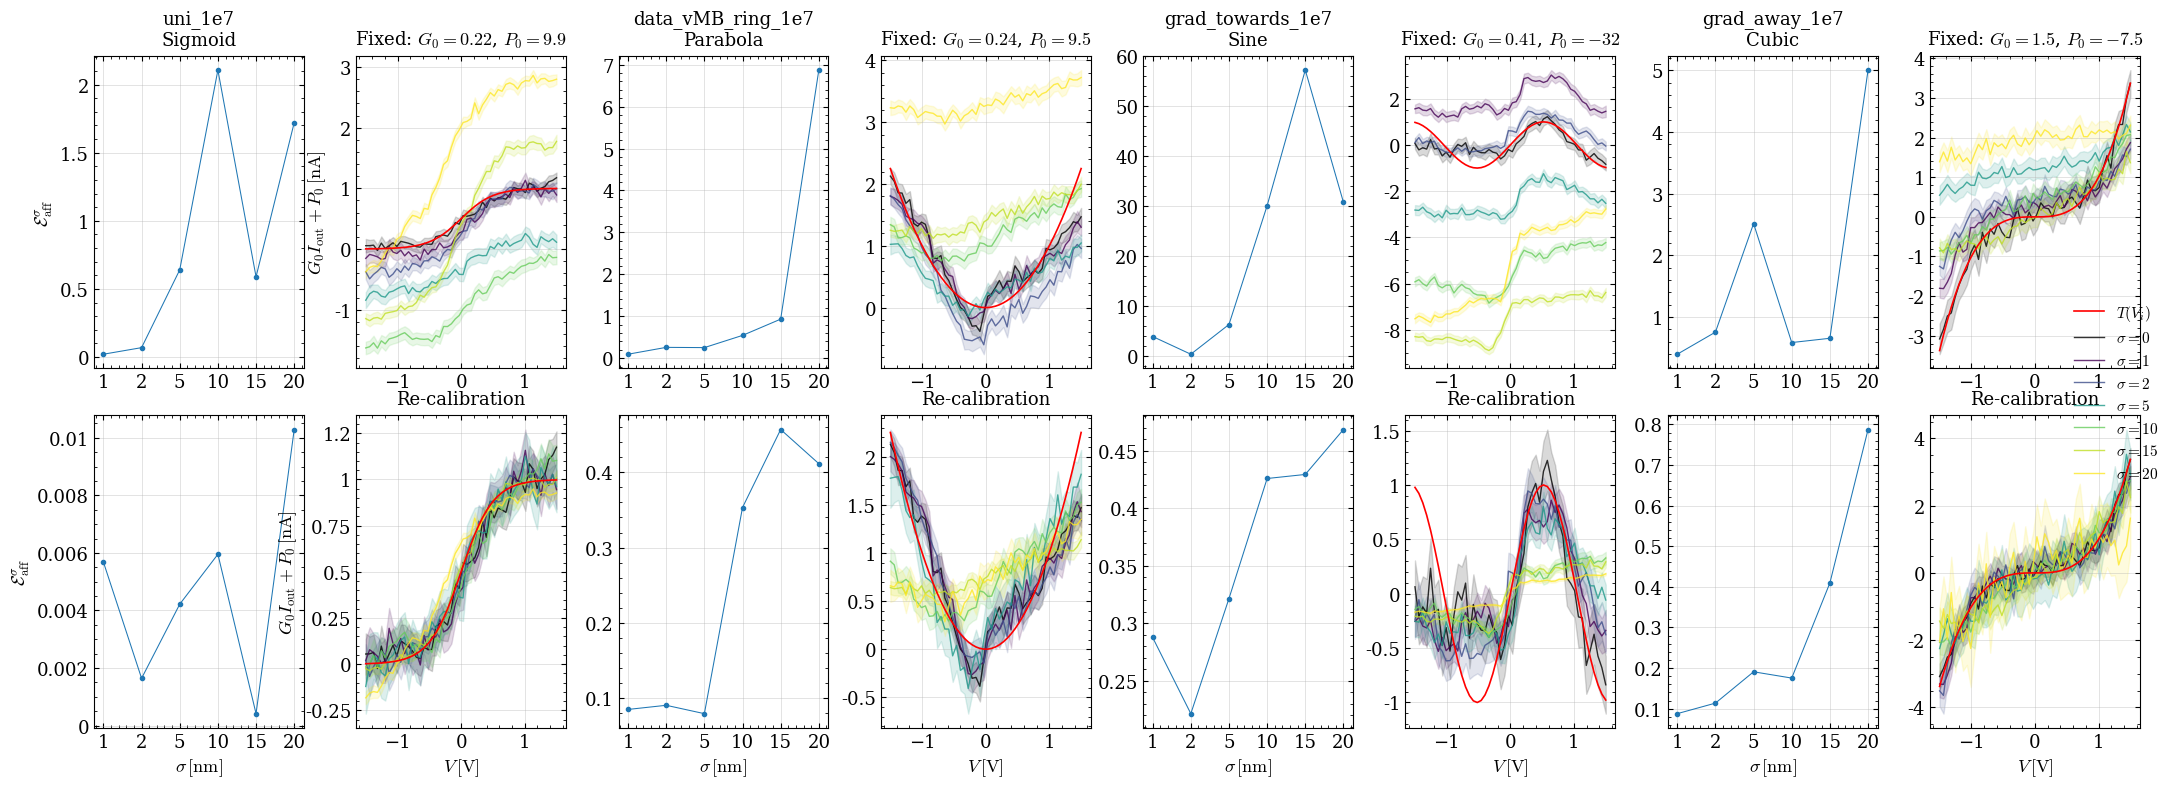

In [3]:
data_dict = {
    "uni_1e7": "Sigmoid",
    "data_vMB_ring_1e7": "Parabola",
    "grad_towards_1e7": "Sine",
    "grad_away_1e7": "Cubic"
}

fig = plot_all_global_vs_recal_grid(
    data_dict=data_dict,
    fit_affine_to_target=fit_affine_to_target,
    mse=mse,
    out_pdf="all_datasets_global_vs_recal.pdf",
    figsize=(22, 8),
    wspace=0.25,
    hspace=0.15,
)

uni_1e7
Sigmoid
data_vMB_ring_1e7
Parabola
grad_towards_1e7
Sine
grad_away_1e7
Cubic


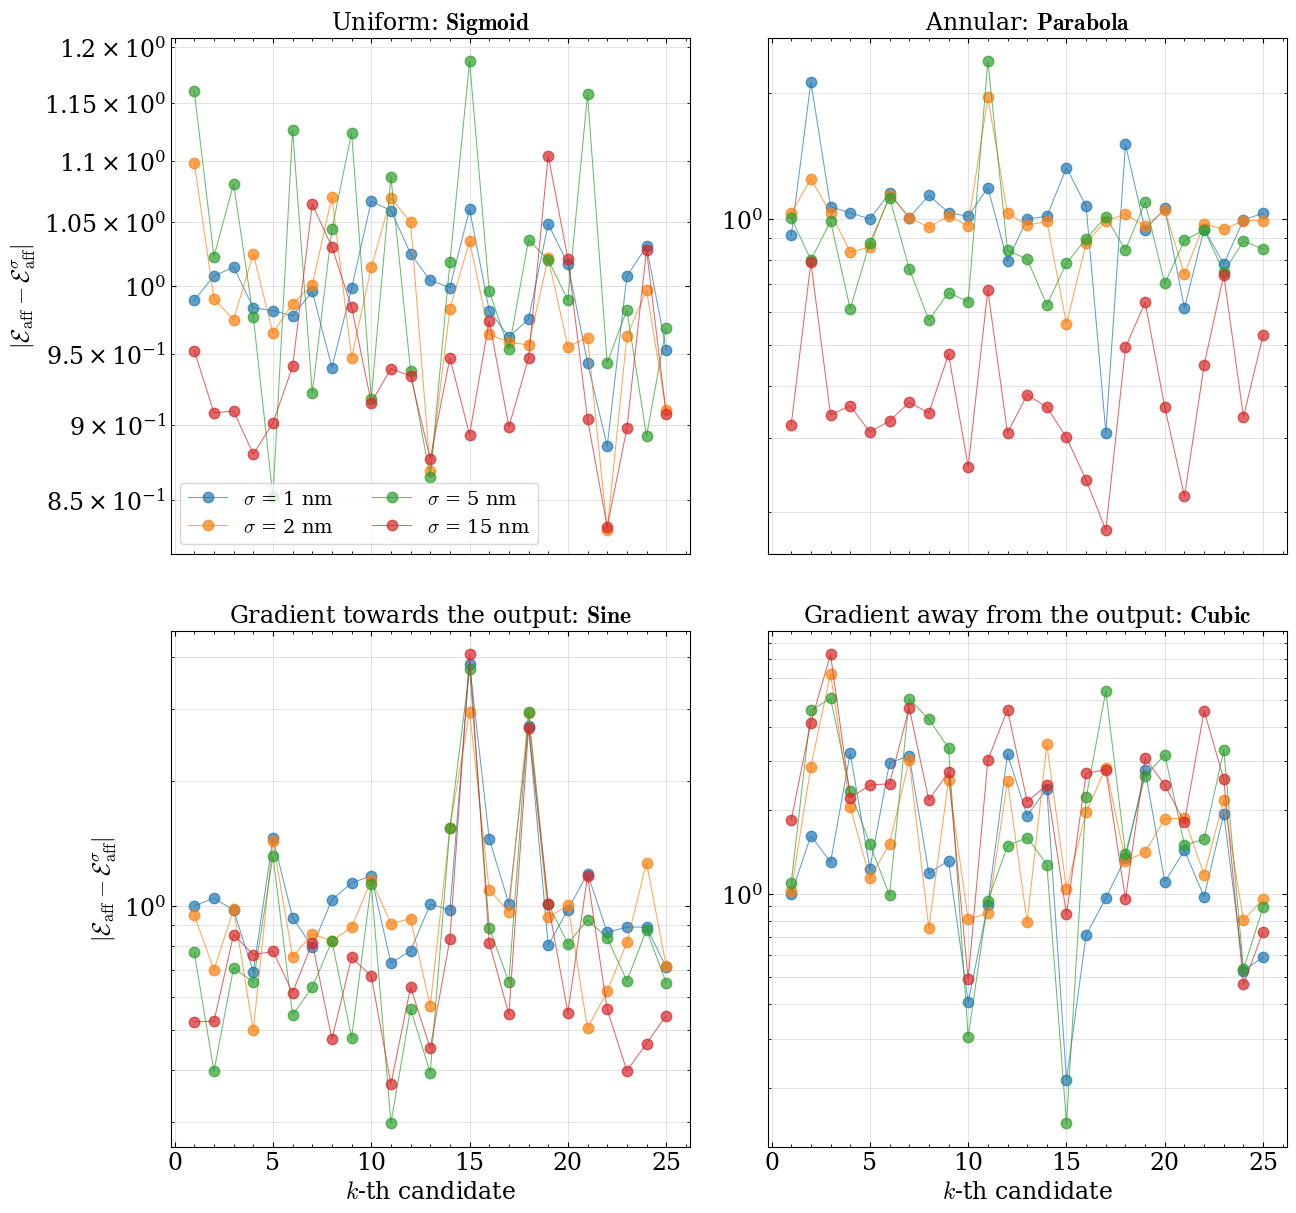

In [6]:
data_dict = {
    "uni_1e7": "Sigmoid",
    "data_vMB_ring_1e7": "Parabola",
    "grad_towards_1e7": "Sine",
    "grad_away_1e7": "Cubic"
}

label_dict = {
    "uni_1e7": r"Uniform: $\mathbf{Sigmoid}$",
    "data_vMB_ring_1e7": "Annular: $\mathbf{Parabola}$",
    "grad_towards_1e7": "Gradient towards the output: $\mathbf{Sine}$",
    "grad_away_1e7": "Gradient away from the output: $\mathbf{Cubic}$"
}

topk_num = 25

#noise_lvl_idx = 0
fig_scale = 3.6
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(4*fig_scale, 4*fig_scale))

label_size = 17
fs = 17
cal_type = 'recal'
noise_indices = [0, 1, 2, 4]
for p, (dt, f) in enumerate(data_dict.items()):
    ground_path = Path(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/jiggled_topks_{dt}_{f}/')
    print(dt)
    print(f)
    ax = axes[p // 2, p % 2]
    score_differences = []
    score_ratios = []
    for noise_lvl_idx in noise_indices:# range(len(noise_strengths)):
        original_scores_l = []
        post_jiggling_scores_l = []
        for k in range(topk_num): 
            ref_data = np.load(
                f"/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/{dt}_{f}_topK/"\
                f"random_mse_func_type={f}_data_type={dt}_topk={k}.npz"
            )
            i_ref = ref_data['current'] * i_scale
            gain_global, offset_global, i_aff_global = fit_affine_to_target(i_ref, y_tgt)
            gain_global, offset_global = gain_global.numpy(), offset_global.numpy()
            
            file_name = ground_path / f"topk={k}_jiggled={noise_lvl_idx}.npz"
            data = np.load(file_name)     
            i_k_l = data['current'] * i_scale
            a_k_l, b_k_l, i_k_l_aff = fit_affine_to_target(i_k_l, y_tgt)
        
            original_scores_l.append(mse(i_aff_global, y_tgt).item())
            if cal_type == 'global':
                post_jiggling_scores_l.append(mse(gain_global*i_k_l+offset_global, y_tgt).item())
            elif cal_type == 'recal':
                post_jiggling_scores_l.append(mse(i_k_l_aff, y_tgt).item())
        diff_in_score = np.array(original_scores_l) - np.array(post_jiggling_scores_l)
        ratio_score = np.array(post_jiggling_scores_l) / np.maximum(np.array(original_scores_l), 1e-12)
        score_differences.append(diff_in_score)
        score_ratios.append(ratio_score)
    
    """for i, d_s in enumerate(score_differences):
        ax.plot(np.arange(1, len(d_s)+1, 1), d_s, marker='o', markersize=7.5, lw=0.75, alpha=0.7, label=f'$\sigma$ = {noise_strengths[noise_indices[i]]} nm')"""
    for i, r_s in enumerate(score_ratios):
        ax.plot(np.arange(1, len(r_s)+1, 1), r_s, marker='o', markersize=7.5, lw=0.75, alpha=0.7, label=f'$\sigma$ = {noise_strengths[noise_indices[i]]} nm')
    
    ax.set_yscale('log')   
    if (p % 2) == 0:
        ax.set_ylabel(r'$\vert \mathcal{E}_{\mathrm{aff}} - \mathcal{E}_{\mathrm{aff}}^{\sigma} \vert$', fontsize=fs)
    ax.minorticks_on()
    ax.tick_params(top=True, right=True, which='both', labelsize=label_size)
    ax.tick_params(direction='in', which='both')
    ax.grid(lw=0.5, alpha=0.5, which='both', axis='y')
    ax.grid(lw=0.5, alpha=0.5, which='major', axis='x')
    ax.tick_params(labelbottom=False, bottom=False)
    if p == 0:
        ax.legend(ncols=2, fontsize=14)
    if (p // 2) == 1:
        ax.tick_params(labelbottom=True, bottom=True)
        ax.tick_params()
        ax.set_xlabel('$k$-th candidate', fontsize=fs)

    ax_title = label_dict[dt]
    ax.set_title(label_dict[dt], fontdict={"fontsize": fs})
#plt.scatter(original_scores, post_jiggling_scores)
fig.subplots_adjust(wspace=0.15, hspace=0.15)
plt.savefig(f'abs_score_differences_against_sigma_{data_type}_{func_type}_{cal_type}.pdf')
plt.show()